In [1]:
import os
import urllib.request
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Setup successful")
print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Setup successful
Torch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


In [2]:
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
import ssl
import urllib.request

url = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
zip_path = RAW_DIR / "EuroSAT.zip"

if not zip_path.exists():
    print("Downloading dataset")
    context = ssl._create_unverified_context()

    opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=context))
    urllib.request.install_opener(opener)

    urllib.request.urlretrieve(url, zip_path)
    print("Download complete")
else:
    print("Dataset already exists")

Dataset already exists


In [4]:
extract_path = RAW_DIR
extracted_folder = RAW_DIR / "2750"

if not extracted_folder.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete")
else:
    print("Dataset already extracted")

Dataset already extracted


In [5]:
data_dir = RAW_DIR / "2750"

classes = [folder.name for folder in data_dir.iterdir() if folder.is_dir()]

In [6]:
class_map = {
    "AnnualCrop": "annual_crop",
    "Forest": "forest",
    "HerbaceousVegetation": "herbaceous_vegetation",
    "Highway": "highway",
    "Industrial": "industrial",
    "Pasture": "pasture",
    "PermanentCrop": "permanent_crop",
    "Residential": "residential",
    "River": "river",
    "SeaLake": "sea_lake"
}

In [7]:
image_paths = []
labels = []

for folder in data_dir.iterdir():
    if folder.is_dir():
        original_class = folder.name
        mapped_class = class_map[original_class]

        for img_file in folder.glob("*"):
            image_paths.append(str(img_file))
            labels.append(mapped_class)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 27000
Total labels: 27000


In [8]:
for i in range(10):
    print(labels[i])

print("\nClass counts:")
print(Counter(labels))

annual_crop
annual_crop
annual_crop
annual_crop
annual_crop
annual_crop
annual_crop
annual_crop
annual_crop
annual_crop

Class counts:
Counter({'annual_crop': 3000, 'forest': 3000, 'herbaceous_vegetation': 3000, 'residential': 3000, 'sea_lake': 3000, 'highway': 2500, 'industrial': 2500, 'permanent_crop': 2500, 'river': 2500, 'pasture': 2000})


In [9]:
label_to_idx = {label: idx for idx, label in enumerate(sorted(set(labels)))}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

numeric_labels = [label_to_idx[label] for label in labels]

print("Label to index mapping:")
print(label_to_idx)

Label to index mapping:
{'annual_crop': 0, 'forest': 1, 'herbaceous_vegetation': 2, 'highway': 3, 'industrial': 4, 'pasture': 5, 'permanent_crop': 6, 'residential': 7, 'river': 8, 'sea_lake': 9}


In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    numeric_labels,
    test_size=0.3,
    random_state=42,
    stratify=numeric_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nTrain class counts:", Counter(y_train))
print("Validation class counts:", Counter(y_val))
print("Test class counts:", Counter(y_test))

Train: 18900
Validation: 4050
Test: 4050

Train class counts: Counter({7: 2100, 9: 2100, 0: 2100, 1: 2100, 2: 2100, 6: 1750, 4: 1750, 3: 1750, 8: 1750, 5: 1400})
Validation class counts: Counter({9: 450, 2: 450, 1: 450, 0: 450, 7: 450, 3: 375, 4: 375, 6: 375, 8: 375, 5: 300})
Test class counts: Counter({9: 450, 0: 450, 7: 450, 1: 450, 2: 450, 6: 375, 4: 375, 3: 375, 8: 375, 5: 300})


In [11]:
class EuroSATDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [12]:
# Added data augmentation
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# No augmentation for validation/test
val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
train_dataset = EuroSATDataset(X_train, y_train, transform=train_transform)
val_dataset   = EuroSATDataset(X_val, y_val, transform=val_test_transform)
test_dataset  = EuroSATDataset(X_test, y_test, transform=val_test_transform)

img, label = train_dataset[0]
print(img.shape)
print(label)

torch.Size([3, 64, 64])
7


In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

images, labels_batch = next(iter(train_loader))
print(images.shape)
print(labels_batch.shape)

torch.Size([64, 3, 64, 64])
torch.Size([64])


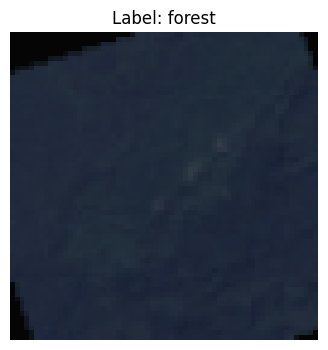

In [15]:
images, labels_batch = next(iter(train_loader))

idx = np.random.randint(0, len(images))
img = images[idx]
label = labels_batch[idx]

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

img = img * std[:, None, None] + mean[:, None, None]
img_np = img.permute(1, 2, 0).numpy().clip(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(img_np)
plt.title(f"Label: {idx_to_label[label.item()]}")
plt.axis("off")
plt.show()

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(label_to_idx))

model = model.to(device)

Using device: cpu


In [17]:
def runEpoch(model, device, dataloader, lossFunction, optimizer=None, train=False):
    if train:
        model.train()
        context = torch.enable_grad()
    else:
        model.eval()
        context = torch.no_grad()

    runningLoss = 0.0
    correct = 0
    total = 0

    with context:
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(inputs)
            loss = lossFunction(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

            runningLoss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epochLoss = runningLoss / len(dataloader)
    accuracy = 100 * correct / total

    return epochLoss, accuracy


def train_model(model, device, epochs, optimizer, lossFunction, fileName):
    bestValidationAccuracy = 0.0

    trainingLossHistory = []
    validationLossHistory = []
    trainingAccuracyHistory = []
    validationAccuracyHistory = []

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}", end=": ")

        epochTrainingLoss, epochTrainingAccuracy = runEpoch(
            model,
            device,
            train_loader,
            lossFunction,
            optimizer=optimizer,
            train=True
        )

        trainingLossHistory.append(epochTrainingLoss)
        trainingAccuracyHistory.append(epochTrainingAccuracy)

        print(
            f"Training Loss: {epochTrainingLoss:.4f}, "
            f"Training Accuracy: {epochTrainingAccuracy:.2f}%",
            end=", "
        )

        epochValidationLoss, epochValidationAccuracy = runEpoch(
            model,
            device,
            val_loader,
            lossFunction,
            optimizer=None,
            train=False
        )

        validationLossHistory.append(epochValidationLoss)
        validationAccuracyHistory.append(epochValidationAccuracy)

        print(
            f"Validation Loss: {epochValidationLoss:.4f}, "
            f"Validation Accuracy: {epochValidationAccuracy:.2f}%"
        )

        if epochValidationAccuracy > bestValidationAccuracy:
            bestValidationAccuracy = epochValidationAccuracy
            torch.save(model.state_dict(), f"Best_Augmented_{fileName}.pth")
            print(f"Saved best model with validation accuracy = {bestValidationAccuracy:.2f}%")

    return (
        trainingLossHistory,
        validationLossHistory,
        trainingAccuracyHistory,
        validationAccuracyHistory
    )

In [18]:
NB_EPOCHS = 32
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

resnet50TrainingLoss, resnet50ValidationLoss, resnet50TrainingAccuracy, resnet50ValidationAccuracy = train_model(
    model,
    device,
    epochs=NB_EPOCHS,
    optimizer=optimizer,
    lossFunction=criterion,
    fileName="ResNet50_Model"
)

Epoch 1/32: Training Loss: 0.6014, Training Accuracy: 81.78%, Validation Loss: 0.1452, Validation Accuracy: 95.26%
Saved best model with validation accuracy = 95.26%
Epoch 2/32: Training Loss: 0.1939, Training Accuracy: 93.79%, Validation Loss: 0.1013, Validation Accuracy: 96.49%
Saved best model with validation accuracy = 96.49%
Epoch 3/32: Training Loss: 0.1470, Training Accuracy: 95.20%, Validation Loss: 0.1034, Validation Accuracy: 96.59%
Saved best model with validation accuracy = 96.59%
Epoch 4/32: Training Loss: 0.1220, Training Accuracy: 95.73%, Validation Loss: 0.0820, Validation Accuracy: 97.33%
Saved best model with validation accuracy = 97.33%
Epoch 5/32: Training Loss: 0.1065, Training Accuracy: 96.38%, Validation Loss: 0.0934, Validation Accuracy: 96.81%
Epoch 6/32: Training Loss: 0.0951, Training Accuracy: 96.76%, Validation Loss: 0.0971, Validation Accuracy: 96.64%
Epoch 7/32: Training Loss: 0.0824, Training Accuracy: 97.26%, Validation Loss: 0.0923, Validation Accuracy

In [19]:
def evaluate(model, device, fileName, test_loader, lossFunction):
    state_dict = torch.load(f"Best_{fileName}.pth", map_location=device)
    model.load_state_dict(state_dict)

    testingLoss, testingAccuracy = runEpoch(
        model,
        device,
        test_loader,
        lossFunction,
        optimizer=None,
        train=False
    )

    print(f"Testing Loss: {testingLoss:.4f}")
    print(f"Testing Accuracy: {testingAccuracy:.2f}%")

evaluate(
    model,
    device,
    "ResNet50_Model",
    test_loader,
    lossFunction=criterion
)

Testing Loss: 0.0705
Testing Accuracy: 97.88%


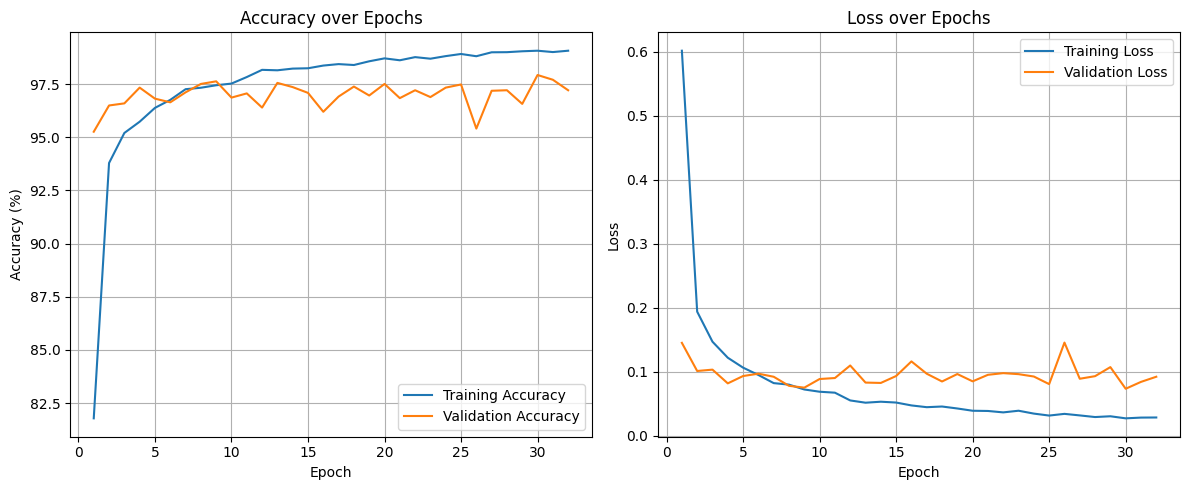

In [20]:
epochs_range = range(1, len(resnet50TrainingLoss) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, resnet50TrainingAccuracy, label='Training Accuracy')
plt.plot(epochs_range, resnet50ValidationAccuracy, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, resnet50TrainingLoss, label='Training Loss')
plt.plot(epochs_range, resnet50ValidationLoss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()